In [1]:
import awkward as ak
import numpy as np
import uproot as uproot
import matplotlib.pyplot as plt
import mplhep as hep
import vector as vec
import pandas as pd

import matplotlib as mpl

plt.style.use(hep.style.CMS)
%matplotlib inline

In [2]:
filenameS = '/eos/user/a/aperego/tagger/tree_Zjj_10k.root'
fileSignal = uproot.open(filenameS)

filenameB = '/eos/user/a/aperego/tagger/tree_DY_10k.root'
fileBkg = uproot.open(filenameB)

In [3]:
def load_branch_with_highest_cycle(file, branch_name):
    # Get all keys in the file
    all_keys = file.keys()
    # Filter keys that match the specified branch name
    matching_keys = [key for key in all_keys if key.startswith(branch_name)]
    if not matching_keys:
        raise ValueError(f"No branch with name '{branch_name}' found in the file.")
    # Find the key with the highest cycle
    highest_cycle_key = max(matching_keys, key=lambda key: int(key.split(";")[1]))
    # Load the branch with the highest cycle
    branch = file[highest_cycle_key]
    return branch

In [4]:
fS_LHEParticles = load_branch_with_highest_cycle(fileSignal, "LHEParticles")
fS_GenJets = load_branch_with_highest_cycle(fileSignal, "GenJets")
fS_GenParticles = load_branch_with_highest_cycle(fileSignal, "GenParticles")

fB_LHEParticles = load_branch_with_highest_cycle(fileBkg, "LHEParticles")
fB_GenJets = load_branch_with_highest_cycle(fileBkg, "GenJets")
fB_GenParticles = load_branch_with_highest_cycle(fileBkg, "GenParticles")

In [5]:
print(fS_LHEParticles.keys())
print(fS_GenJets.keys())
print(fS_GenParticles.keys())

['LHEPart_pt', 'LHEPart_eta', 'LHEPart_phi', 'LHEPart_mass', 'LHEPart_pdgId', 'LHEPart_status']
['GenJet_pt', 'GenJet_eta', 'GenJet_phi', 'GenJet_mass', 'GenJet_nConstituents', 'GenJet_constituents']
['nGenPart', 'GenPart_pt', 'GenPart_eta', 'GenPart_phi', 'GenPart_mass', 'GenPart_pdgId']


In [6]:
LHEParticles_s = fS_LHEParticles.arrays(fS_LHEParticles.keys())
GenJets_s = fS_GenJets.arrays(fS_GenJets.keys())
GenParticles_s = fS_GenParticles.arrays(fS_GenParticles.keys())

LHEParticles_b = fB_LHEParticles.arrays(fB_LHEParticles.keys())
GenJets_b = fB_GenJets.arrays(fB_GenJets.keys())
GenParticles_b = fB_GenParticles.arrays(fB_GenParticles.keys())

In [7]:
def getJetConstituents(i, nConst, allConst):
    return allConst[sum(nConst[:i]):sum(nConst[:i+1])]

In [8]:
def getManyJetsConstituents(i, j, nConst, allConst):
    return allConst[sum(nConst[:i]):sum(nConst[:j+1])]

In [9]:
getManyJetsConstituents(0,3, GenJets_b.GenJet_nConstituents[0], GenJets_b.GenJet_constituents[0])

<Array [692, 378, 689, 376, ... 261, 33, 140] type='125 * int32'>

## features

In [10]:
def pull_angle(jpa, jpb):
    t = jpa+jpb
    v = vec.obj(rho=1, eta=jpa.eta-jpb.eta, phi=jpa.phi-jpb.eta)
    tp = t@v
    
    return tp
def jet_colour_ring(jeta, jetb, gluon):
    dak = (jeta.eta-gluon.eta)**2 + (jeta.phi-gluon.phi)**2
    dbk = (jetb.eta-gluon.eta)**2 + (jetb.phi-gluon.phi)**2
    dab = (jeta.eta-jetb.eta)**2  + (jeta.phi-jetb.phi)**2
    
    return (dak+dbk)/dab

def event_jet_pull(GenJets, GenParticles, ev):
    genjets_pt = GenJets.GenJet_pt[ev]
    nConstituents = GenJets.GenJet_nConstituents[ev]
    constituents = GenJets.GenJet_constituents[ev]
    genParts_pt = GenParticles.GenPart_pt[ev]
    genParts_eta = GenParticles.GenPart_eta[ev]
    genParts_phi = GenParticles.GenPart_phi[ev]
    genJets_eta = GenJets.GenJet_eta[ev]
    genJets_phi = GenJets.GenJet_phi[ev]
        
    NJETS = len(GenJets.GenJet_pt[ev])
    genjets_pull = []
    
    pulls_m = []
    pulls_eta = []
    pulls_phi = []
    
    
    for i in range(NJETS):
        pull_m = 0
        pull_eta = 0
        pull_phi = 0
        
        genPartsInJetIndices = getJetConstituents(i, nConstituents, constituents)
        
        cs_pt  = genParts_pt[genPartsInJetIndices]
        cs_eta = genParts_eta[genPartsInJetIndices]
        cs_phi = genParts_phi[genPartsInJetIndices]
        
        jet_pt  = GenJets.GenJet_pt[ev][i]
        jet_eta = GenJets.GenJet_eta[ev][i]
        jet_phi = GenJets.GenJet_phi[ev][i]
        
        for c_pt, c_eta, c_phi in zip(cs_pt, cs_eta, cs_phi):
            pti = c_pt
            ri2 = (c_eta-jet_eta)**2+(c_phi-jet_phi)**2
            m = pti*ri2
            pull_m += m
            pull_eta += (c_eta-jet_eta)*m
            pull_phi += (c_phi-jet_phi)*m

        
        pull_m /= jet_pt
        pull_eta /= jet_pt
        pull_phi /= jet_pt
        
        pulls_m.append(pull_m)
        pulls_eta.append(pull_eta)
        pulls_phi.append(pull_phi)
        
        
    
    return pulls_m, pulls_eta, pulls_phi


In [11]:
from numba import njit
import awkward.numba

@njit
def getJetConstituents_numba(i, nConst, allConst):
    start = 0
    for j in range(i):
        start += nConst[j]
    end = start + nConst[i]
    return allConst[start:end]

@njit
def wrapInPhi_numba(phi):
    x = (phi + np.pi) % (2 * np.pi) - np.pi
    return x

@njit
def event_jet_pull_numba(GenJets, GenParticles, ev):
    genjets_pt = GenJets.GenJet_pt[ev]
    nConstituents = GenJets.GenJet_nConstituents[ev]
    constituents = GenJets.GenJet_constituents[ev]
    genParts_pt = GenParticles.GenPart_pt[ev]
    genParts_eta = GenParticles.GenPart_eta[ev]
    genParts_phi = GenParticles.GenPart_phi[ev]
    genJets_eta = GenJets.GenJet_eta[ev]
    genJets_phi = GenJets.GenJet_phi[ev]
      
    pulls_m = []
    pulls_eta = []
    pulls_phi = []
    
    for i in range(len(GenJets.GenJet_pt[ev])):
        pull_m = 0
        pull_eta = 0
        pull_phi = 0
        
        genPartsInJetIndices = getJetConstituents_numba(i, nConstituents, constituents)

        cs_pt =[]
        cs_eta =[]
        cs_phi =[]
                
        for gpidx in genPartsInJetIndices:
            cs_pt.append(genParts_pt[gpidx])
            cs_eta.append(genParts_eta[gpidx])
            cs_phi.append(genParts_phi[gpidx])
        
        # print ('cs_pt', cs_pt)
        
        jet_pt  = GenJets.GenJet_pt[ev][i]
        jet_eta = GenJets.GenJet_eta[ev][i]
        jet_phi = GenJets.GenJet_phi[ev][i]
        
        jet_phi = wrapInPhi_numba(jet_phi)        
        
        for c_pt, c_eta, c_phi in zip(cs_pt, cs_eta, cs_phi):
            c_phi = wrapInPhi_numba(c_phi)
            pti = c_pt
            ri2 = (c_eta-jet_eta)**2+wrapInPhi_numba(c_phi-jet_phi)**2
            m = pti*ri2
            pull_m += m
            pull_eta += (c_eta-jet_eta)*m
            pull_phi += wrapInPhi_numba(c_phi-jet_phi)*m

        
        pull_m /= jet_pt
        pull_eta /= jet_pt
        pull_phi /= jet_pt
        
        pulls_m.append(pull_m)
        pulls_eta.append(pull_eta)
        pulls_phi.append(pull_phi)
        
        
    
    return pulls_m, pulls_eta, pulls_phi

In [12]:
jets_pull_s = [[],[],[]]
jets_pull_b = [[],[],[]]
for i in range(len(GenJets_s)):
    pulls_signal = event_jet_pull_numba(GenJets_s, GenParticles_s, i)
    jets_pull_s[0].append(pulls_signal[0])    
    jets_pull_s[1].append(pulls_signal[1])    
    jets_pull_s[2].append(pulls_signal[2])  
    pulls_bkg = event_jet_pull_numba(GenJets_b, GenParticles_b, i)
    jets_pull_b[0].append(pulls_bkg[0])
    jets_pull_b[1].append(pulls_bkg[1])    
    jets_pull_b[2].append(pulls_bkg[2])    

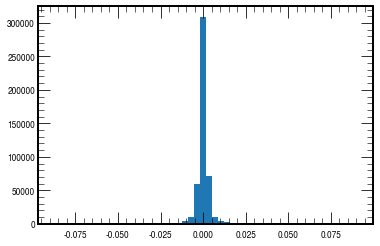

In [13]:
plt.hist([p for pulls in jets_pull_s[2] for p in pulls], bins=50)
plt.show()

## input to GNN

In [14]:
def wrapInPhi(phi):
    """Map angle values to the range [-pi, pi]."""
    return (phi + np.pi) % (2 * np.pi) - np.pi

In [15]:
def getJetsDataFrame(GenJets, jets_pull, isSignal, verbose=False):
    genJets_pt = GenJets.GenJet_pt
    genJets_eta = GenJets.GenJet_eta
    genJets_phi = wrapInPhi(GenJets.GenJet_phi)
    genJets_mass = GenJets.GenJet_mass
    nConstituents = GenJets.GenJet_nConstituents
    events_id = np.concatenate([np.ones(len(genJets_pt[idx]))*idx for idx in range(len(genJets_pt))])
    if not isSignal:
        events_id += 10000
        
    # Flatten the arrays (along axis=0, combining the particles from all events)
    flat_pt = ak.flatten(genJets_pt)
    flat_eta = ak.flatten(genJets_eta)
    flat_phi = ak.flatten(genJets_phi)
    flat_mass = ak.flatten(genJets_mass)
    jetpull_m = [p for pulls in jets_pull[0] for p in pulls]
    jetpull_eta = [p for pulls in jets_pull[1] for p in pulls]
    jetpull_phi = [p for pulls in jets_pull[2] for p in pulls]
    flat_nConstituents = ak.flatten(nConstituents)
    labels = ak.ones_like(flat_pt) if isSignal else ak.zeros_like(flat_pt)

    # Create a pandas DataFrame
    df = pd.DataFrame({
        'ev': events_id,
        'pt': flat_pt,
        'eta': flat_eta,
        'phi': flat_phi,
        'mass': flat_mass,
        'ncostituents': flat_nConstituents,
        'jetpull_m': jetpull_m,
        'jetpull_eta': jetpull_eta,
        'jetpull_phi': jetpull_phi,
        'label': labels
    })
    df['ev'] = df['ev'].astype(int)
    
    return df

In [16]:
dfS = getJetsDataFrame(GenJets_s, jets_pull_s, True)
dfB = getJetsDataFrame(GenJets_b, jets_pull_b, False)

In [17]:
### LEPTONS, bkg
def getLeptonsDataFrame(LHEParticles, isSignal, verbose=False):
    lhePart_pgdid = (10 < abs(LHEParticles.LHEPart_pdgId)) & (abs(LHEParticles.LHEPart_pdgId) < 20)

    lhePart_pt = LHEParticles.LHEPart_pt[lhePart_pgdid]
    lhePart_eta = LHEParticles.LHEPart_eta[lhePart_pgdid]
    lhePart_phi = wrapInPhi(LHEParticles.LHEPart_phi[lhePart_pgdid])
    lhePart_mass = LHEParticles.LHEPart_mass[lhePart_pgdid]

    events_id = np.concatenate([np.ones(len(lhePart_pt[idx]))*idx for idx in range(len(lhePart_pt))])
    if not isSignal:
        events_id += 10000

    # Flatten the arrays (along axis=0, combining the particles from all events)
    flat_pt = ak.flatten(lhePart_pt)
    flat_eta = ak.flatten(lhePart_eta)
    flat_phi = ak.flatten(lhePart_phi)
    flat_mass = ak.flatten(lhePart_mass) 
    ncostituents = ak.zeros_like(flat_mass)
    jetpull = ak.zeros_like(flat_mass)
    label = ak.ones_like(flat_pt) if isSignal else ak.zeros_like(flat_pt)

    # Create a pandas DataFrame
    df = pd.DataFrame({
        'ev': events_id,
        'pt': flat_pt,
        'eta': flat_eta,
        'phi': flat_phi,
        'mass': flat_mass,
        'ncostituents': ncostituents,
        'jetpull': jetpull,
        'label': label
    })

    df['ev'] = df['ev'].astype(int)
    df['ncostituents'] = df['ncostituents'].astype(int)
    df['label'] = df['label'].astype(int)

    if verbose:
        print(df)
    return df

In [18]:
# dfLS = getLeptonsDataFrame(LHEParticles_s, True)
# dfLB = getLeptonsDataFrame(LHEParticles_b, False)
df = pd.concat([dfS, dfB], axis=0, ignore_index=True)

## evaluate scaling

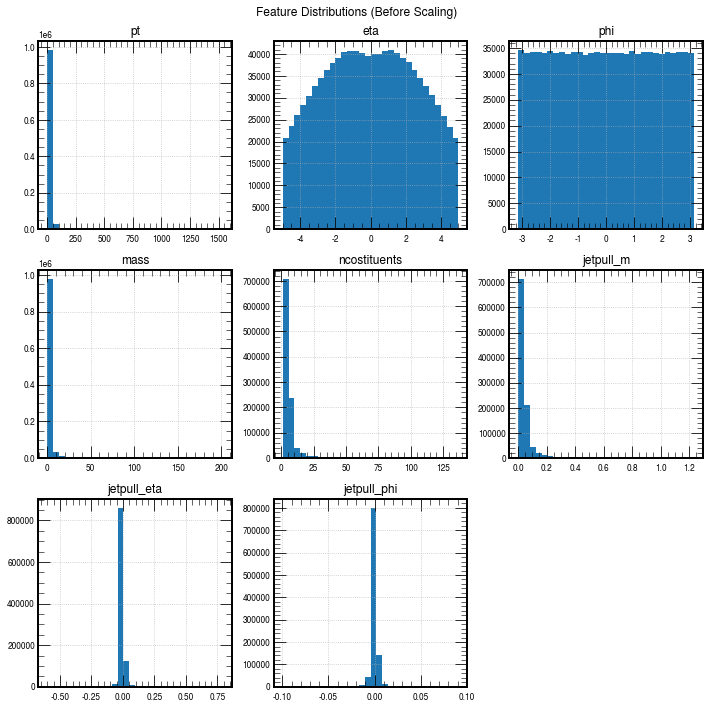

In [19]:
# Assuming df is your DataFrame with the mentioned columns
columns_to_plot = ['pt', 'eta', 'phi', 'mass', 'ncostituents', 'jetpull_m', 'jetpull_eta', 'jetpull_phi']

# Create histograms for each feature
df[columns_to_plot].hist(bins=30, figsize=(10, 10))
plt.suptitle('Feature Distributions (Before Scaling)')
plt.tight_layout()
plt.show()

/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


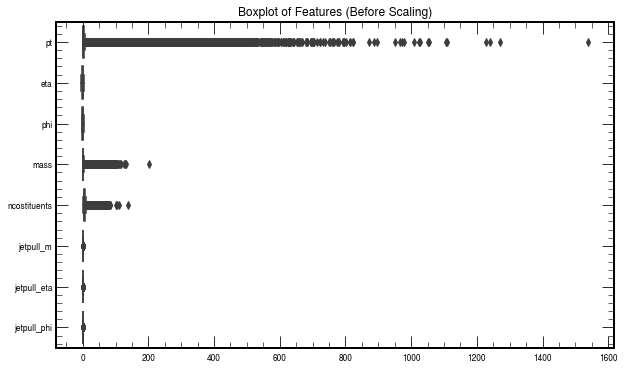

In [20]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[columns_to_plot], orient="h")
plt.title('Boxplot of Features (Before Scaling)')
plt.show()

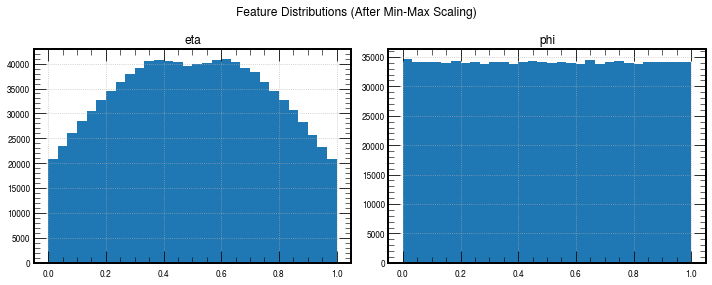

In [21]:
from sklearn.preprocessing import MinMaxScaler

# Apply Min-Max scaling
scaler = MinMaxScaler()
columns_linear = ['eta', 'phi']
df_scaled_linear = pd.DataFrame(scaler.fit_transform(df[columns_linear]), columns=columns_linear)

# Plot the rescaled data
df_scaled_linear.hist(bins=30, figsize=(10, 4))
plt.suptitle('Feature Distributions (After Min-Max Scaling)')
plt.tight_layout()
plt.show()

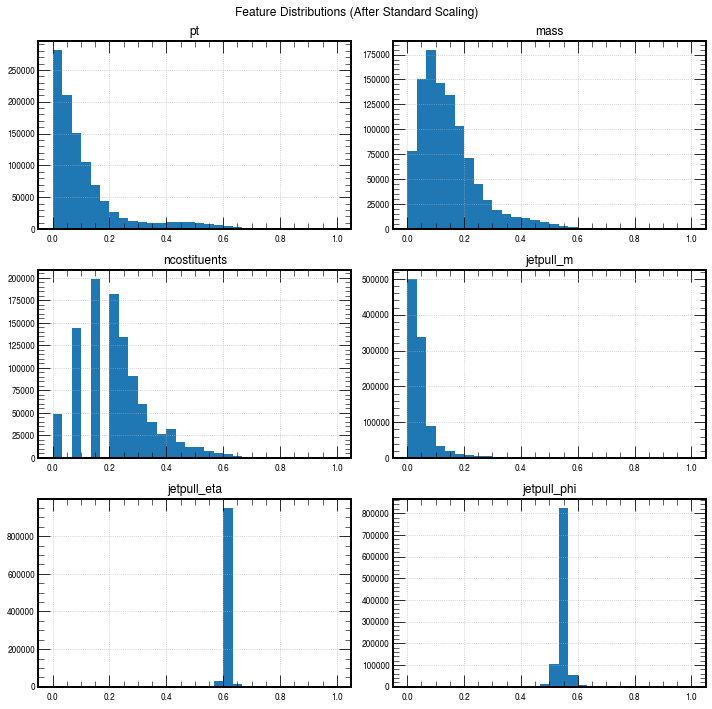

In [22]:
import numpy as np

# Apply log scaling (add a small constant to avoid log(0))
log_columns = ['pt', 'mass', 'ncostituents', 'jetpull_m', 'jetpull_eta', 'jetpull_phi']
df_scaled_log = df[log_columns].apply(lambda x: np.log1p(x))

from sklearn.preprocessing import StandardScaler

# Apply Standard Scaling (Z-score normalization)
scaler = MinMaxScaler()
df_standard_scaled = pd.DataFrame(scaler.fit_transform(df_scaled_log), columns=log_columns)
# Plot the standardized data
df_standard_scaled.hist(bins=30, figsize=(10, 10))
plt.suptitle('Feature Distributions (After Standard Scaling)')
plt.tight_layout()
plt.show()

/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


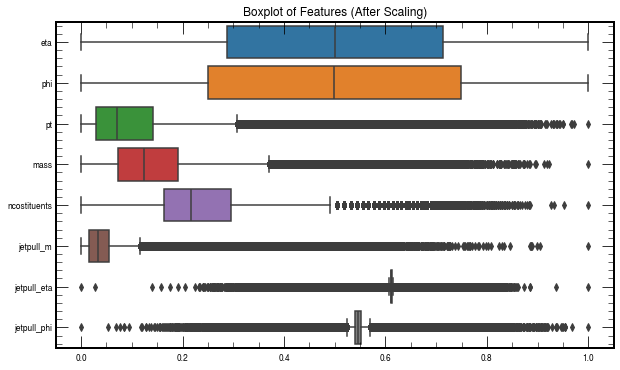

In [23]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=pd.concat((df_scaled_linear,df_standard_scaled)), orient="h")
plt.title('Boxplot of Features (After Scaling)')
plt.show()

In [24]:
df_other = df[["ev","label"]]

In [25]:
df_combined = pd.concat([df_scaled_linear, df_scaled_log, df_other], axis=1)
df = df_combined

In [26]:
df

,eta,phi,pt,mass,ncostituents,jetpull_m,jetpull_eta,jetpull_phi,ev,label
0,0.204151,0.928886,3.599668,1.470518,2.564949,0.005264,-0.000199,-0.000507,0,1.0
1,0.520768,0.445385,3.078070,1.279530,2.079442,0.004626,-0.000337,-0.000277,0,1.0
2,0.918636,0.932950,2.146906,1.144902,2.079442,0.033690,-0.001937,0.000257,0,1.0
3,0.459091,0.399624,2.048440,1.230434,1.945910,0.022403,0.000267,0.000325,0,1.0
4,0.234458,0.221615,1.839871,0.895897,1.791759,0.024257,-0.004409,0.003505,0,1.0
...,...,...,...,...,...,...,...,...,...,...
1023214,0.778266,0.007033,0.763653,0.302216,1.386294,0.019069,-0.001064,0.002065,19999,0.0
1023215,0.053332,0.798467,0.711024,0.126615,1.098612,0.016871,-0.000841,0.002355,19999,0.0
1023216,0.559439,0.682397,0.709232,0.213045,1.098612,0.025274,0.000556,-0.002975,19999,0.0
1023217,0.500426,0.024514,0.698567,0.288792,1.098612,0.028316,-0.001432,0.002048,19999,0.0


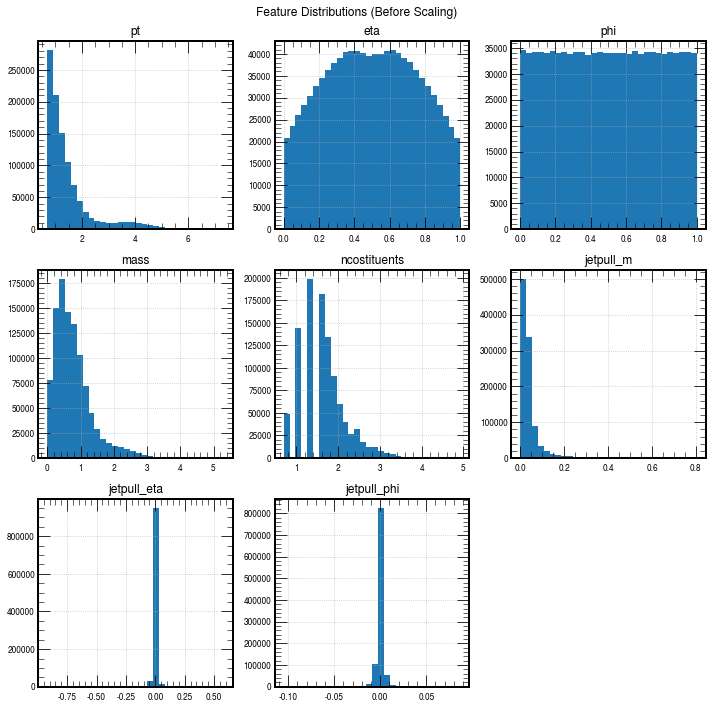

In [27]:
# Assuming df is your DataFrame with the mentioned columns
columns_to_plot = ['pt', 'eta', 'phi', 'mass', 'ncostituents', 'jetpull_m', 'jetpull_eta', 'jetpull_phi']

# Create histograms for each feature
df[columns_to_plot].hist(bins=30, figsize=(10, 10))
plt.suptitle('Feature Distributions (Before Scaling)')
plt.tight_layout()
plt.show()

## train test split

In [28]:
NEVENTS = 20000
train_events = np.random.choice(np.arange(NEVENTS), size=int(NEVENTS*0.9), replace=False)

df_train = df[df['ev'].isin(train_events)]
df_test = df[~df['ev'].isin(train_events)]

def shuffle_df(df):
    # shuffle the events in the df
    unique_ev = df['ev'].unique()
    # Shuffle the unique 'ev' values
    shuffled_ev = np.random.permutation(unique_ev)
    # Create a mapping from old ev to new shuffled ev
    ev_mapping = dict(zip(unique_ev, shuffled_ev))
    # Replace 'ev' column with the shuffled values using the mapping
    df['ev'] = df['ev'].map(ev_mapping)
    df_sorted = df.sort_values(by='ev')
    return df_sorted

df_train = shuffle_df(df_train)
df_test = shuffle_df(df_train)

/tmp/ipykernel_307/1906082154.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ev'] = df['ev'].map(ev_mapping)


(array([490822.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0., 431805.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

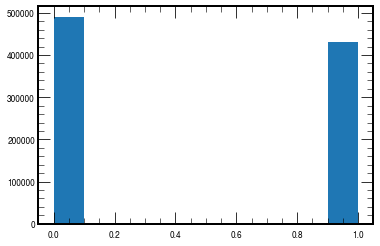

In [29]:
plt.hist(df_train['label'])

(array([490822.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0., 431805.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

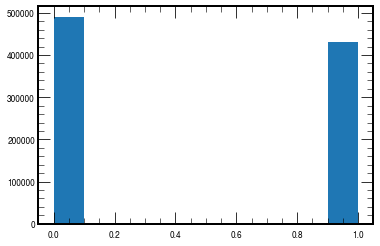

In [30]:
plt.hist(df_test['label'])

## GNN

In [31]:
# install Pytorch Geometric
import torch
print(torch.__version__)

import torch_geometric
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import FixedPoints
from sklearn.model_selection import train_test_split
from torch_cluster import knn_graph

2.1.0a0


In [32]:
# NEW

class MyGraphDataset(torch_geometric.data.Dataset):
    def __init__(self, data, k=5, transform=None, pre_transform=None):
        super(MyGraphDataset, self).__init__(transform, pre_transform)
        self.data_l = data[['ev','label']]
        self.data_f = data.drop(columns=['label'])
        self.num_samples = data['ev'].nunique()
        self.k = k # number of nearest neighbors
        self.uniqueIndices = data['ev'].unique()

    def len(self):
        return self.num_samples

    def get(self, idx):   
        evIdx = self.uniqueIndices[idx]
        graph_data = self.data_f[self.data_f["ev"]==evIdx]
#         print(self.data_l[self.data_l["ev"]==evIdx])
        graph_label = self.data_l[self.data_l["ev"]==evIdx]['label'].unique()

        #pos_tmp = graph_data[sel]
        pos = torch.tensor(graph_data[['eta', 'phi']].values, dtype=torch.float32) #eta_rel and phi_rel
        x = torch.tensor(graph_data[['pt', 'mass', 'ncostituents', 'jetpull_m', 'jetpull_eta', 'jetpull_phi']].values, dtype=torch.float32)
#         print("graph_label=", graph_label, '\nfirst row=', self.data_l[self.data_l["ev"]==evIdx].iloc[[0]])
        y = torch.tensor(graph_label, dtype=torch.long)
#         print("y=",y)
        
        # compute edge_index (using pos)
        # fix: phi is wrap: change distance definition -> coseno invece di euclidea (sin^2 diff degli angoli /2)
        edge_index = knn_graph(pos, k=self.k, loop=False)
        

        # pyg data object
        data = Data(x=x, y=y, pos=pos, edge_index=edge_index, category=y)

        return data

In [33]:
# # ORIGINAL

# from time import time

# class MyGraphDataset(torch_geometric.data.Dataset):
#     def __init__(self, data, k=5, transform=None, pre_transform=None):
#         super(MyGraphDataset, self).__init__(transform, pre_transform)
        
#         all_f = []
#         all_l = []
#         for ev in data['ev'].unique():
#             data_ev = data[data['ev'] == ev]
#             all_l.append(data_ev[['eta', 'phi', 'pt', 'mass', 'ncostituents']].values)
#             all_f.append(int(data['label'].iloc[0]))
        
#         self.data_l = all_f
#         self.data_f = all_l
#         self.num_samples = data['ev'].nunique()
#         self.k = k # number of nearest neighbors

#     def len(self):
#         return self.num_samples

#     def get(self, idx):   
# #         start = time()
#         graph_data = self.data_f[idx]
#         graph_label = self.data_l[idx]
# #         print(time()-start)

#         pos = torch.tensor(graph_data[:,:2], dtype=torch.float32) #eta_rel and phi_rel
#         x = torch.tensor(graph_data[:,2:], dtype=torch.float32)
#         y = torch.tensor(int(graph_label), dtype=torch.long)
# #         print(time()-start)
        
#         # compute edge_index (using pos)
#         # fix: phi is wrap: change distance definition -> coseno invece di euclidea (sin^2 diff degli angoli /2)
#         edge_index = knn_graph(pos, k=self.k, loop=False)
# #         print(time()-start)
        

#         # pyg data object
#         data = Data(x=x, y=y, pos=pos, edge_index=edge_index)
# #         print(time()-start)

#         return data

In [34]:
# number of nearest neighbors
k = 5

# Create Datasets
trainset = MyGraphDataset(df_train, k=k)
# validset = MyGraphDataset(X_valid, y_valid, k=k)
testset = MyGraphDataset(df_test, k=k)

# Create DataLoaders
trainloader = DataLoader(trainset, batch_size=256, shuffle=True, drop_last=True,num_workers=8)
validloader = DataLoader(testset, batch_size=256, shuffle=False, drop_last=False)
testloader = DataLoader(testset, batch_size=4, shuffle=False, drop_last=False,num_workers=8)

In [35]:
for i in range(10):
    print(testset[i])

Data(x=[57, 6], edge_index=[2, 285], y=[1], pos=[57, 2], category=[1])
Data(x=[46, 6], edge_index=[2, 230], y=[1], pos=[46, 2], category=[1])
Data(x=[67, 6], edge_index=[2, 335], y=[1], pos=[67, 2], category=[1])
Data(x=[35, 6], edge_index=[2, 175], y=[1], pos=[35, 2], category=[1])
Data(x=[40, 6], edge_index=[2, 200], y=[1], pos=[40, 2], category=[1])
Data(x=[73, 6], edge_index=[2, 365], y=[1], pos=[73, 2], category=[1])
Data(x=[76, 6], edge_index=[2, 380], y=[1], pos=[76, 2], category=[1])
Data(x=[36, 6], edge_index=[2, 180], y=[1], pos=[36, 2], category=[1])
Data(x=[21, 6], edge_index=[2, 105], y=[1], pos=[21, 2], category=[1])
Data(x=[58, 6], edge_index=[2, 290], y=[1], pos=[58, 2], category=[1])


In [36]:
d = next(iter(trainloader))
d.batch

/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

tensor([  0,   0,   0,  ..., 255, 255, 255])

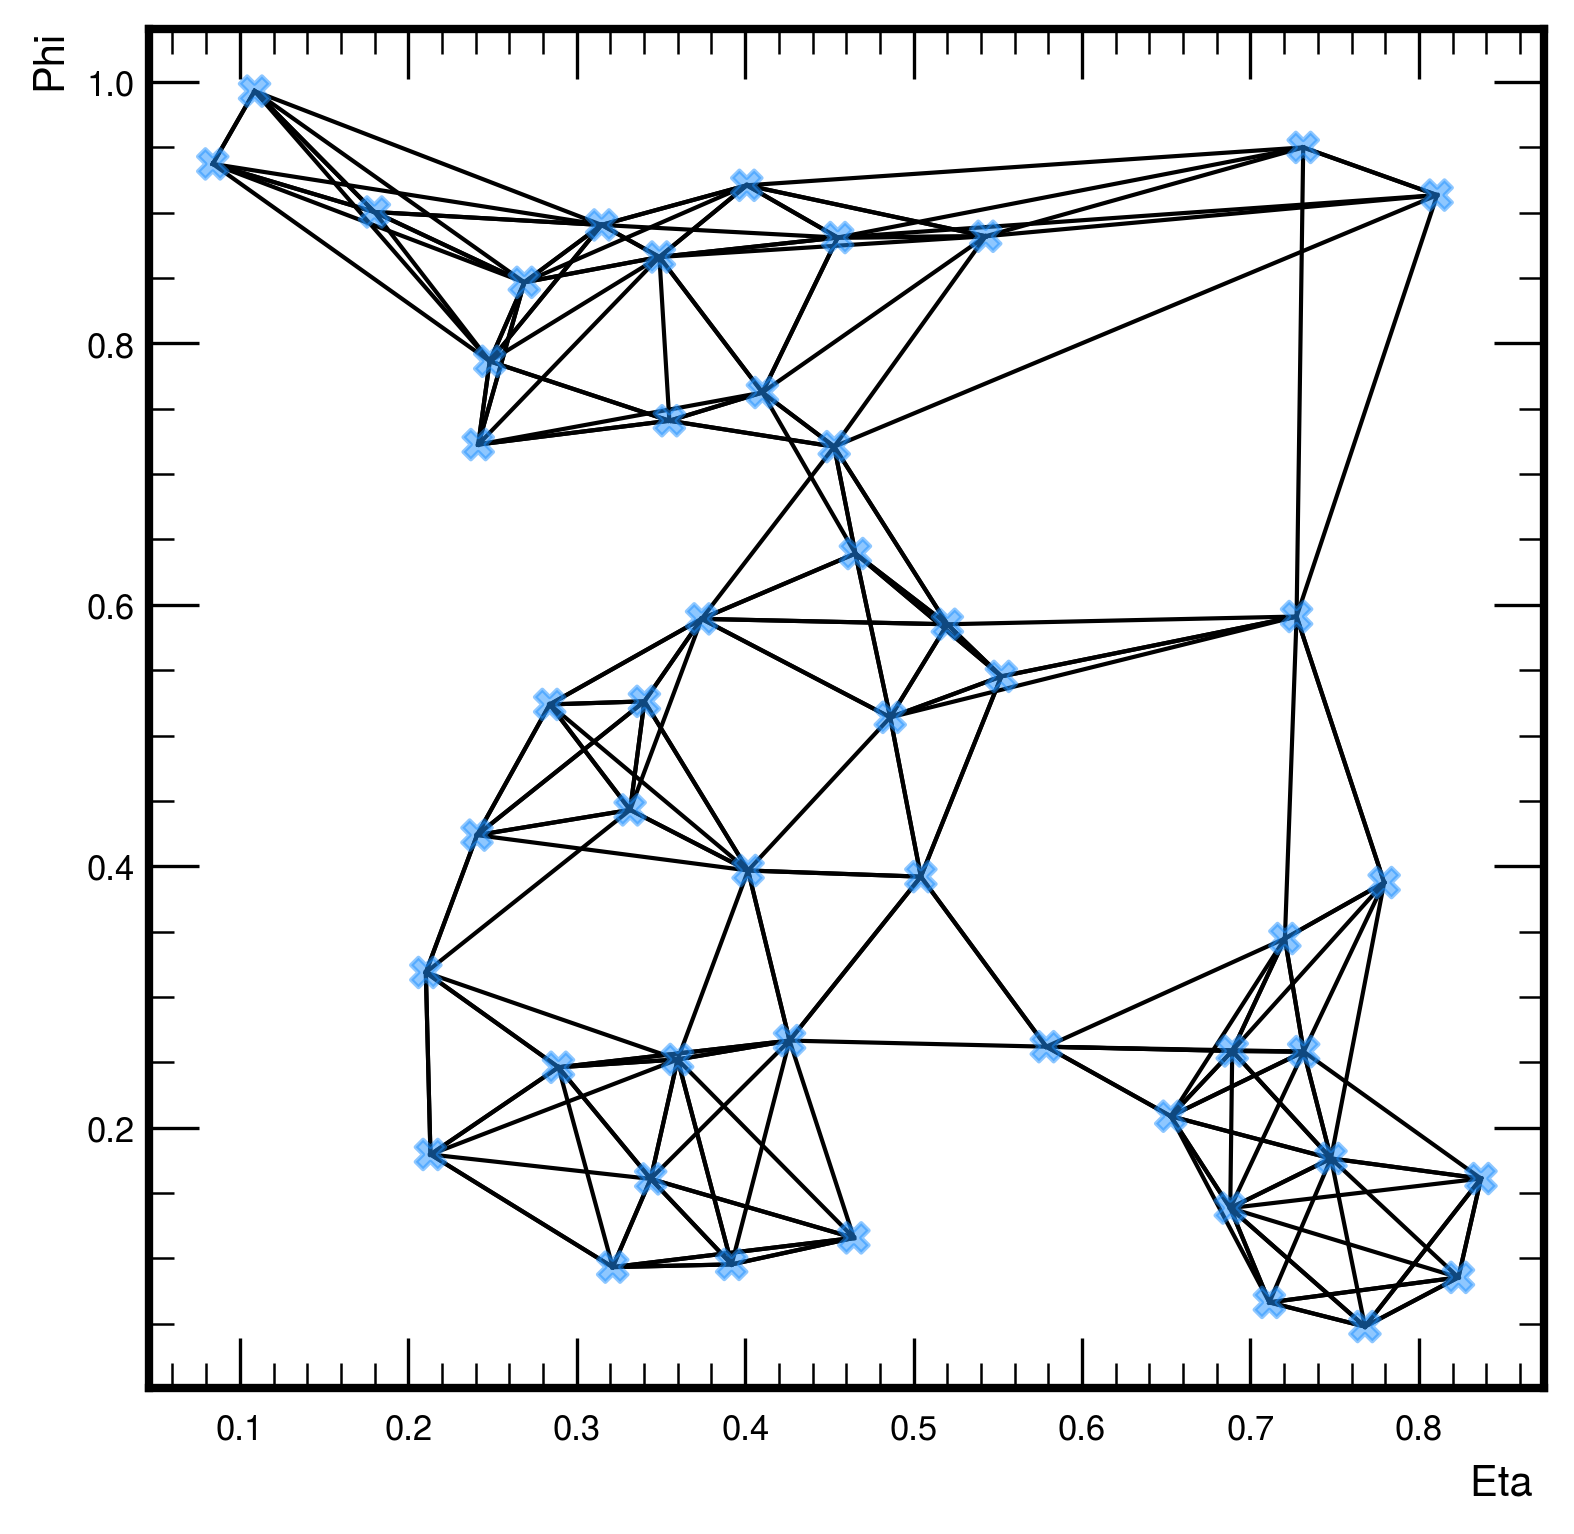

In [38]:
def visualize_points(pos, x, edge_index=None):
    fig = plt.figure(figsize=(6, 6), dpi=300)
    if edge_index is not None:
        for (src, dst) in edge_index.t().tolist():
             src = pos[src].tolist()
             dst = pos[dst].tolist()
             plt.plot([src[0], dst[0]], [src[1], dst[1]], linewidth=1, color='black')
    colors = []
    style = []
    
    for i in x[:,2]:
        if i == 0: 
            colors.append('red')
            style.append('X')
        else: 
            colors.append('dodgerblue')
            style.append('o')

    # facecolors='None', edgecolors='orange'
    colors = colors[2:]+colors[:2]
    x = list(pos[2:, 0])+list(pos[:2, 0])
    y = list(pos[2:, 1])+list(pos[:2, 1])
    plt.scatter(x, y, c = colors, marker='X',alpha=0.5, s=50, zorder=1000)
#     plt.xlim((-5,5))
#     plt.ylim((-np.pi, np.pi))
    plt.xlabel('Eta ')
    plt.ylabel('Phi')
    plt.show()

data = trainset[2]

visualize_points(data.pos, data.x, data.edge_index)

In [39]:
from matplotlib import colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())
def get_color(index):
    wrapped_index = index % len(colors)
    return colors[wrapped_index]

/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

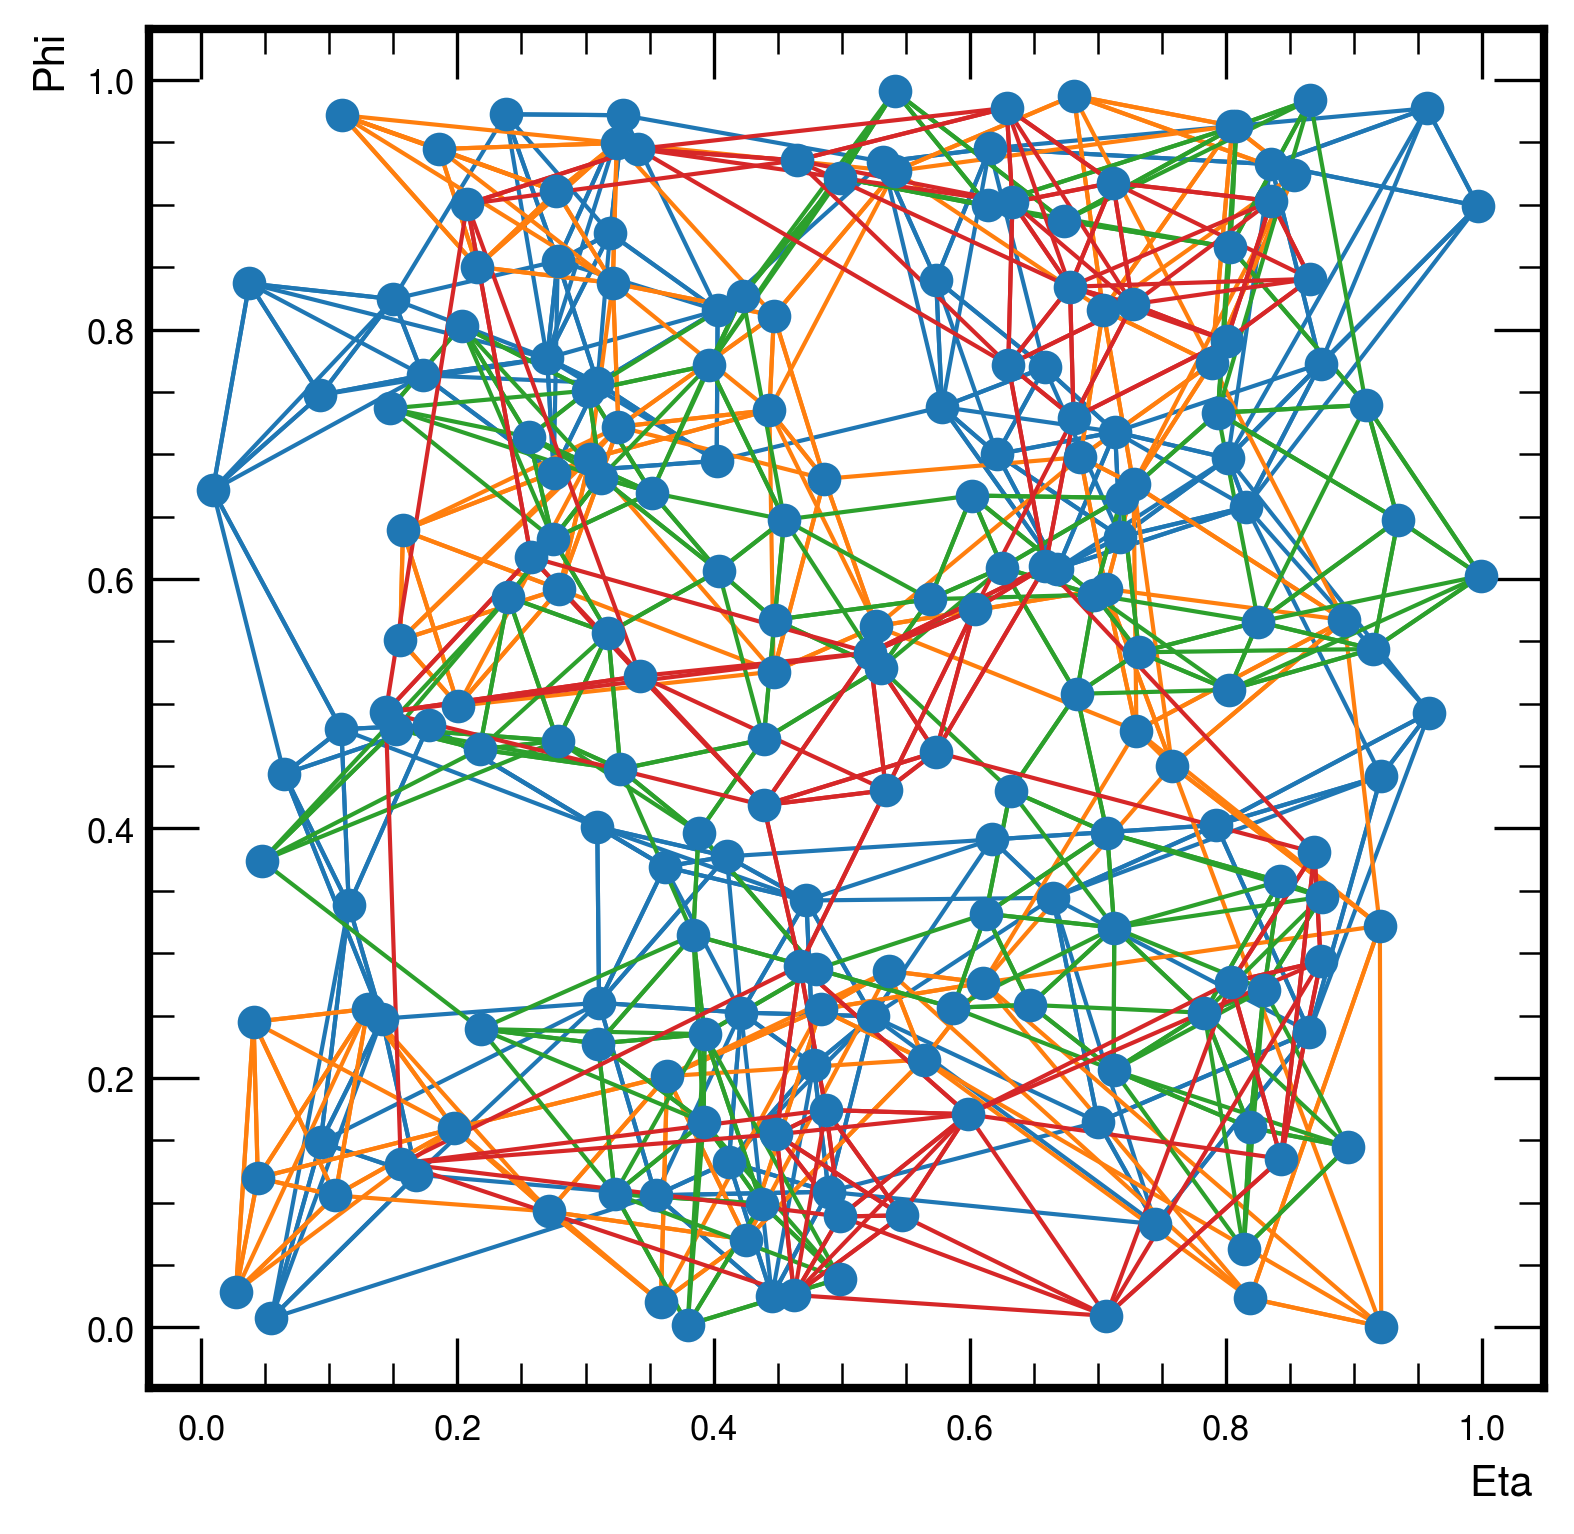

In [42]:
def visualize_batch(pos, x, edge_index=None, batch=None):
    fig = plt.figure(figsize=(6, 6), dpi=300)
        
    if edge_index is not None:
        for (src, dst) in edge_index.t().tolist():
             if batch is not None:
                 c=get_color(batch[src])
             else:
                 c="black"
             src = pos[src].tolist()
             dst = pos[dst].tolist()
             
             plt.plot([src[0], dst[0]], [src[1], dst[1]], linewidth=1, color=c)
            
   
    plt.scatter(pos[:, 0], pos[:, 1], s=50, zorder=1000)
   

    plt.axis('on')
#     plt.xlim((-5,5))
#     plt.ylim((-np.pi, np.pi))
    plt.xlabel('Eta ')
    plt.ylabel('Phi')
    plt.show()
data = next(iter(testloader))
visualize_batch(data.pos,data.x, data.edge_index,data.batch)

In [43]:
# GNN model in pytorch geometric: we'll use a simple convolutional GNN based on the GCNConv message passing graph convolution
# https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html


import torch.nn as nn
from torch_geometric.nn import GCNConv, global_max_pool,PointNetConv,global_mean_pool
from torch_geometric.nn.norm import BatchNorm
from torch_geometric.utils import dropout_node,dropout_edge
import torch.nn.functional as F

class GNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GNN, self).__init__()
        self.pre_feat = nn.Linear(input_dim, hidden_dim)
        self.pre_feat2 = nn.Linear(hidden_dim, hidden_dim)
        self.conv1 = GCNConv(hidden_dim, hidden_dim)
        self.bn1 =BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 =BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 =BatchNorm(hidden_dim)
        #self.conv4 = GCNConv(hidden_dim, hidden_dim)
        #self.bn4 =BatchNorm(hidden_dim)
        #self.conv5 = GCNConv(hidden_dim, hidden_dim)
        #self.bn5 =BatchNorm(hidden_dim)
        #self.conv6 = GCNConv(hidden_dim, hidden_dim)
        #self.bn6 =BatchNorm(hidden_dim)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        # when loading data use .unsqueeze(1) if the data has only one column
        pos, feat, edge_index, batch = data.pos, data.x, data.edge_index, data.batch
        feat = torch.cat((feat, pos), dim=1)

        feat = F.relu(self.pre_feat(feat))
        feat = F.relu(self.pre_feat2(feat))
        feat = F.dropout(feat, p=0.5, training=self.training)

        x = F.relu(self.conv1(feat, edge_index))
        x = self.bn1(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.bn2(x)
#         x = F.relu(self.conv3(x, edge_index))
#         x = self.bn3(x)
        x = x + feat
        x = global_mean_pool(x, batch)  # Aggregate node features
        x = F.dropout(x, p=0.5, training=self.training)
        x =  F.relu(self.fc(x))
        x = self.fc2(x)
        return x

In [45]:
# test the model on one batch
from torch_geometric.nn import summary
model = GNN(input_dim=8, hidden_dim=128, output_dim=5)
data = next(iter(trainloader))
output = model(data)

/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

In [46]:
print(output.shape)
print(summary(model, data))

torch.Size([256, 5])
+----------------------------+--------------------------+----------------+----------+
| Layer                      | Input Shape              | Output Shape   | #Param   |
|----------------------------+--------------------------+----------------+----------|
| GNN                        | [12880, 12880]           | [256, 5]       | 85,125   |
| ├─(pre_feat)Linear         | [12880, 8]               | [12880, 128]   | 1,152    |
| ├─(pre_feat2)Linear        | [12880, 128]             | [12880, 128]   | 16,512   |
| ├─(conv1)GCNConv           | [12880, 128], [2, 64400] | [12880, 128]   | 16,512   |
| ├─(bn1)BatchNorm           | [12880, 128]             | [12880, 128]   | 256      |
| │    └─(module)BatchNorm1d | [12880, 128]             | [12880, 128]   | 256      |
| ├─(conv2)GCNConv           | [12880, 128], [2, 64400] | [12880, 128]   | 16,512   |
| ├─(bn2)BatchNorm           | [12880, 128]             | [12880, 128]   | 256      |
| │    └─(module)BatchNorm1d | [1

In [47]:
import torch_scatter
print(torch_scatter.__version__)

2.1.1


In [50]:
import time
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# move model to GPU
model = GNN(input_dim=8, hidden_dim=128, output_dim=8).to(device)

# initialize loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10, verbose=True)

# training loop
num_epochs = 50
train_losses, valid_losses = [], []
train_accuracies, valid_accuracies = [], []
best_valid_loss = float('inf')

all_true_labels_lastEpoch = []
all_pred_probs_lastEpoch = []

for epoch in range(num_epochs):
    start_time = time.time()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    # set model to training mode
    model.train()
    for i, batch in enumerate(trainloader):
        batch = batch.to(device)
        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch.y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch.y.size(0)
        train_correct += (predicted == batch.y).sum().item()

    # Validation
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    # Variables to store true labels and predicted probabilities for ROC/AUC calculation
    all_true_labels = []
    all_pred_probs = []

    # set model to evaluation mode
    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(validloader):
            batch = batch.to(device)
            outputs = model(batch)
            loss = criterion(outputs, batch.y)
            valid_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            valid_total += batch.y.size(0)
            valid_correct += (predicted == batch.y).sum().item()

            # Store true labels and predicted probabilities
            all_true_labels.extend(batch.y.cpu().numpy())
            all_pred_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())  # Probabilities for class 1

    # Calculate epoch metrics
    train_accuracy = 100 * train_correct / train_total
    valid_accuracy = 100 * valid_correct / valid_total
    epoch_time = time.time() - start_time

    # Print and store metrics
    print('Epoch %d: train loss: %.3f, train acc: %.3f%%, valid loss: %.3f, valid acc: %.3f%%, time: %.3fs' %
          (epoch + 1, train_loss / len(trainloader), train_accuracy,
           valid_loss / len(validloader), valid_accuracy, epoch_time))

    train_losses.append(train_loss / len(trainloader))
    valid_losses.append(valid_loss / len(validloader))
    train_accuracies.append(train_accuracy)
    valid_accuracies.append(valid_accuracy)
    scheduler.step(valid_accuracy)
    print("lr: ", optimizer.param_groups[0]['lr'])

    # Save model if validation loss improves
    if valid_loss / len(validloader) < best_valid_loss:
        best_valid_loss = valid_loss / len(validloader)
        torch.save(model.state_dict(), 'best_model_gnn.pth')
        print("Model saved!")
    
    
    all_true_labels_lastEpoch = all_true_labels
    all_pred_probs_lastEpoch = all_pred_probs


cuda


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

Epoch 1: train loss: 0.734, train acc: 60.396%, valid loss: 0.906, valid acc: 54.350%, time: 108.832s
lr:  0.03
Model saved!


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

Epoch 2: train loss: 0.603, train acc: 68.075%, valid loss: 0.598, valid acc: 69.889%, time: 102.426s
lr:  0.03
Model saved!


...

Epoch 48: train loss: 0.492, train acc: 76.568%, valid loss: 0.497, valid acc: 75.517%, time: 102.226s
lr:  0.015


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

Epoch 49: train loss: 0.499, train acc: 75.971%, valid loss: 0.500, valid acc: 76.072%, time: 99.468s
lr:  0.015


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

Epoch 50: train loss: 0.494, train acc: 76.468%, valid loss: 0.558, valid acc: 71.983%, time: 101.603s
lr:  0.015


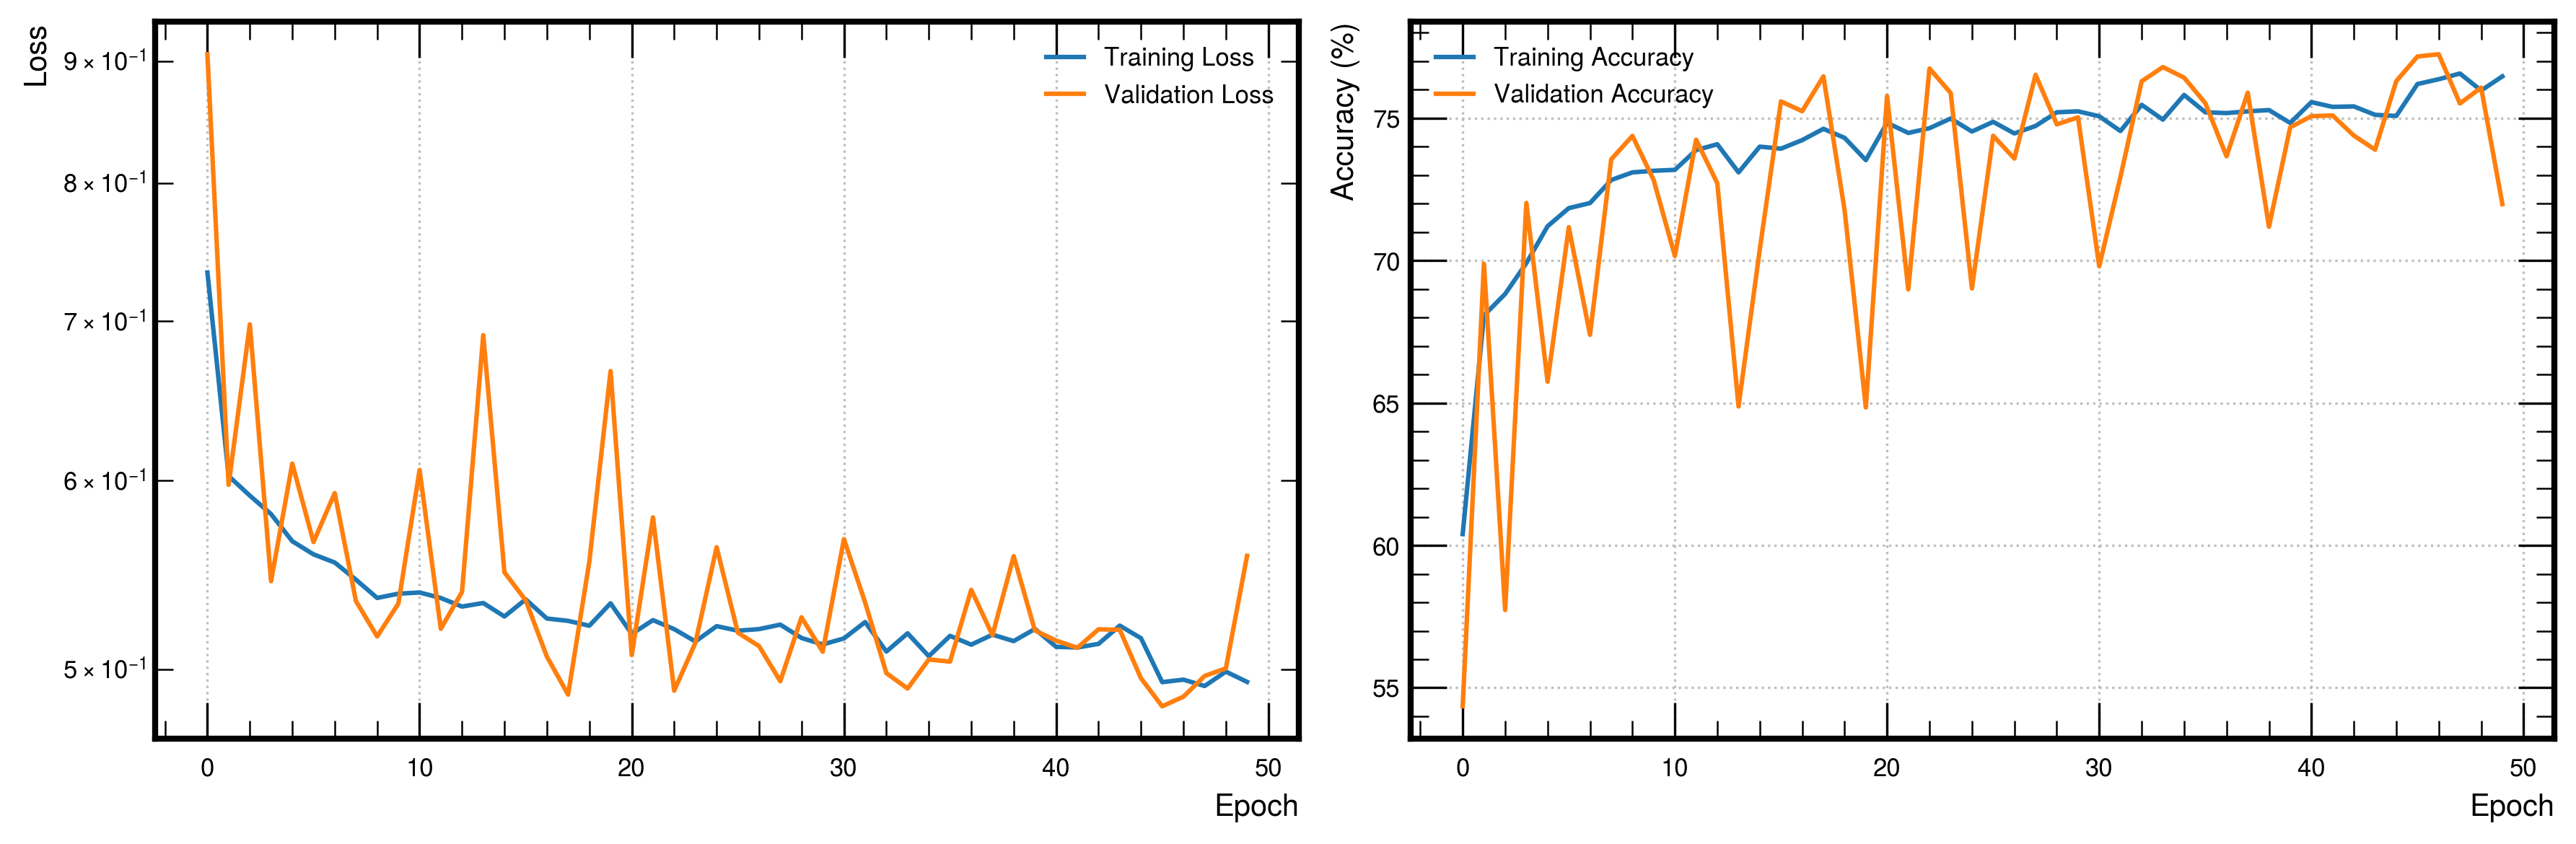

In [51]:
# plot loss and accuracy vs epoch for training and validation

# Plot loss and accuracy
plt.figure(figsize=(12, 4), dpi=300)

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid("on")
plt.yscale("log")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(valid_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid("on")

plt.tight_layout()
plt.savefig("lossAndAccNew.png")

In [52]:
# # Calculate ROC and AUC for validation
# fpr, tpr, _ = roc_curve(all_true_labels_lastEpoch, all_pred_probs_lastEpoch)
# roc_auc = auc(fpr, tpr)

# # Plot ROC curve for validation
# plt.figure(dpi=300, facecolor='white',figsize=(6,6))
# # plt.axis("equal")
# plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.0])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title(f'Receiver Operating Characteristic (ROC) - Epoch {epoch + 1}')
# plt.legend(loc='lower right')
# plt.grid(True)
# plt.savefig("ROC.png")

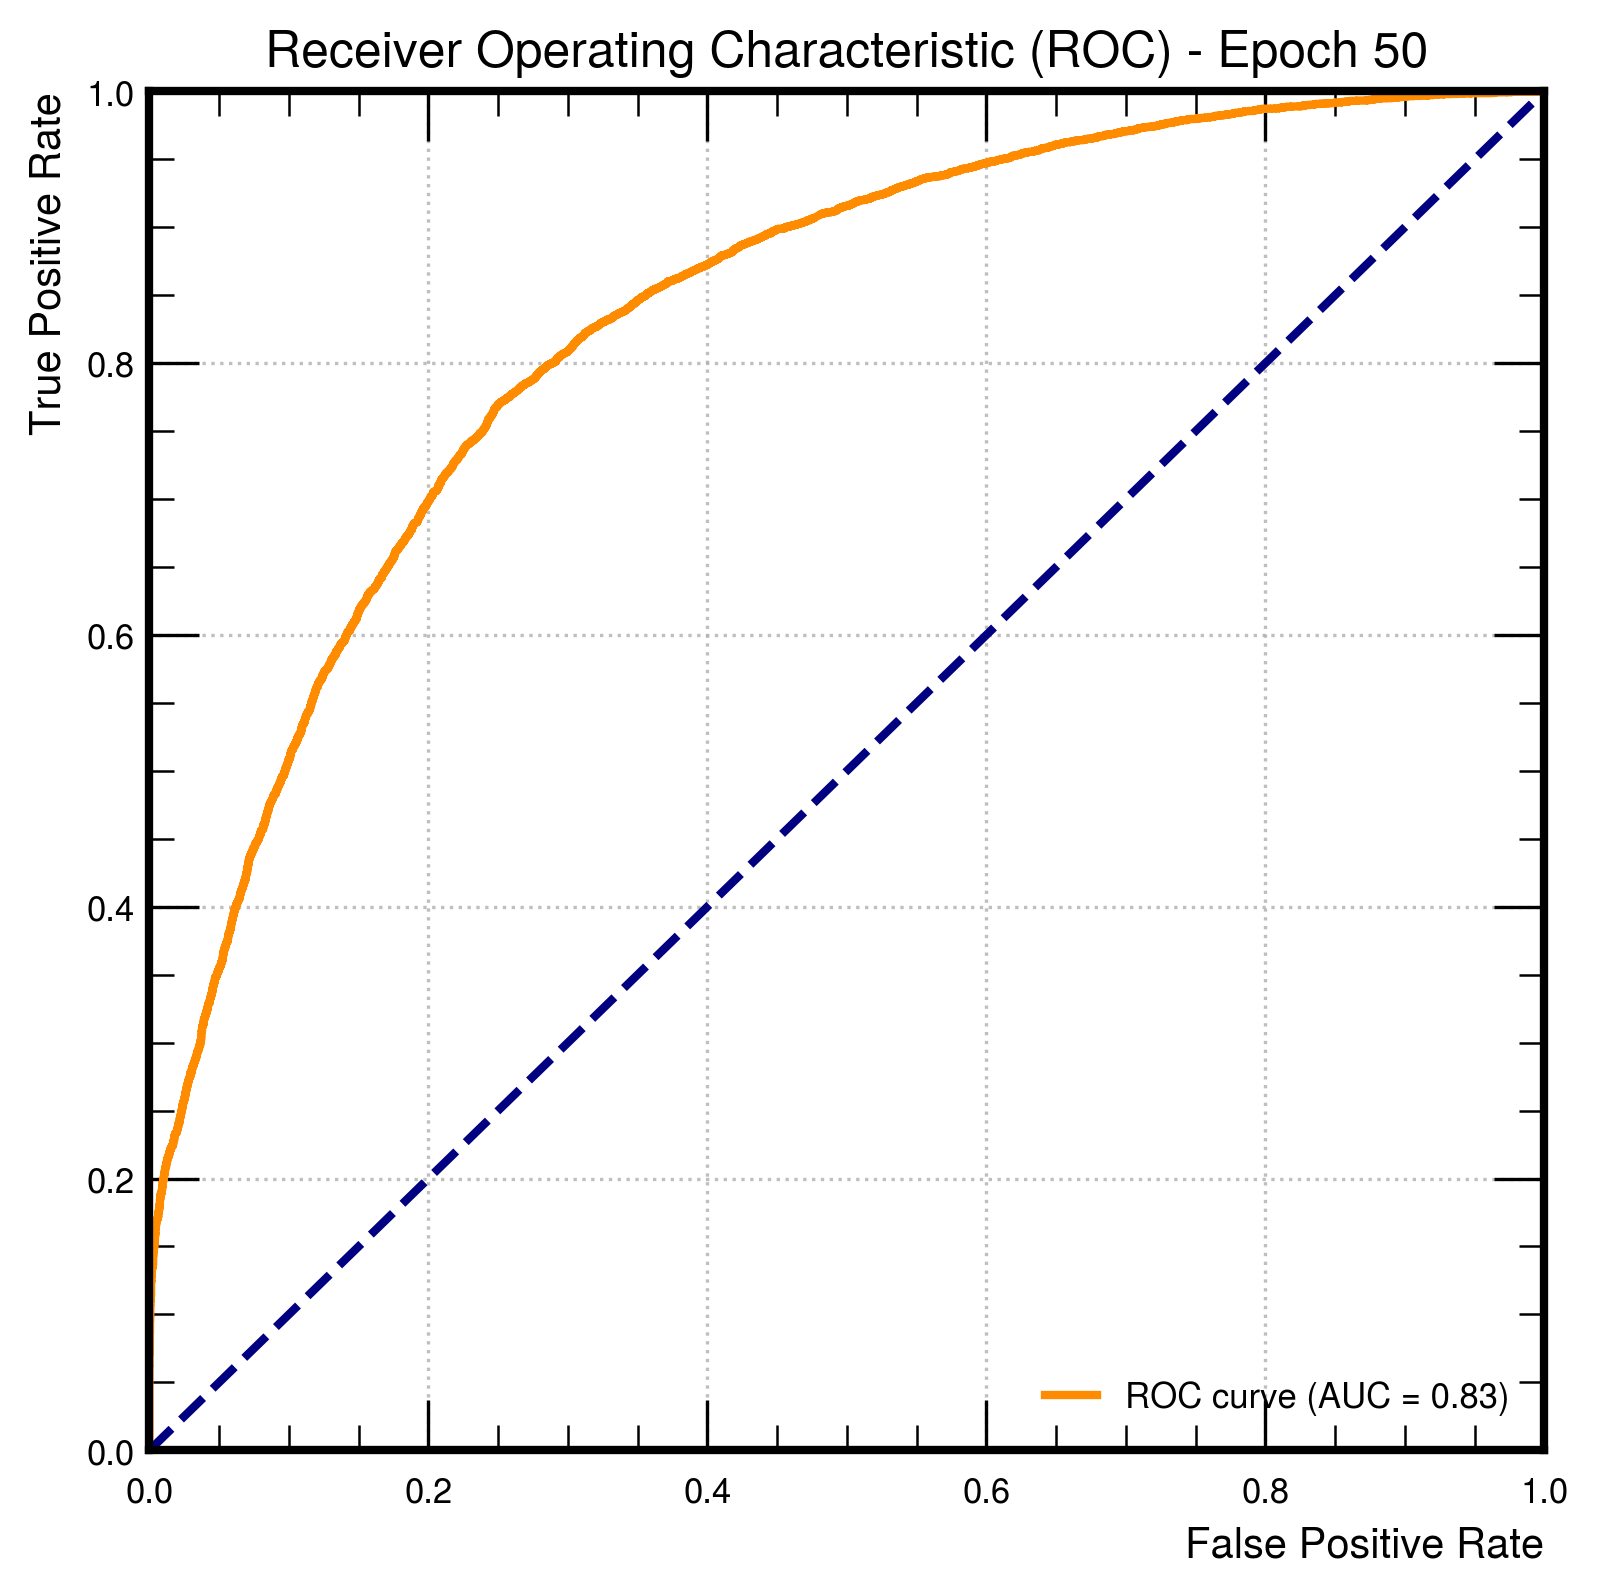

In [53]:
# Calculate ROC and AUC for validation
fpr, tpr, _ = roc_curve(all_true_labels_lastEpoch, all_pred_probs_lastEpoch)
roc_auc = auc(fpr, tpr)

# Plot ROC curve for validation
plt.figure(dpi=300, facecolor='white',figsize=(6,6))
# plt.axis("equal")
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) - Epoch {epoch + 1}')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("ROCnew.png")